In [1]:
from sklearn import datasets

digits = datasets.load_digits()
data, target = digits.data, digits.target
data.shape, target.shape

((1797, 64), (1797,))

In [2]:
# Cada imagen es una matriz de 8x8 pixeles aplanada a 64 columnas

digits.images.shape

(1797, 8, 8)

In [3]:
# Rango de intensidad de los pixeles

data.min(), data.max()

(0.0, 16.0)

In [4]:
# Distribucion de las clases

import pandas as pd

pd.Series(target).value_counts().sort_index()

0    178
1    182
2    177
3    183
4    181
5    182
6    181
7    179
8    174
9    180
Name: count, dtype: int64

In [5]:
# Visualizacion de las primeras imagenes

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(8, 4))

for ax, image, label in zip(axes.ravel(), digits.images, target):
    ax.imshow(image, cmap="gray_r")
    ax.set_title(label)
    ax.axis("off")

plt.tight_layout()
plt.show()

<Figure size 800x400 with 10 Axes>

In [6]:
# Seleccion del modelo por validacion cruzada estratificada
#
# El dataset viene ordenado por escritor, por lo que se usa shuffle
# para que cada pliegue sea representativo.

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

candidatos = {
    "knn_3": KNeighborsClassifier(n_neighbors=3),
    "mlp_64": MLPClassifier(hidden_layer_sizes=(64,), max_iter=3000, random_state=42),
    "svc_C1": SVC(kernel="rbf", C=1, gamma="scale", random_state=42),
    "svc_C5": SVC(kernel="rbf", C=5, gamma=0.005, random_state=42),
    "svc_C50": SVC(kernel="rbf", C=50, gamma=0.005, random_state=42),
}

resultados = []

for nombre, clasificador in candidatos.items():
    modelo = Pipeline(
        [
            ("scaler", StandardScaler()),
            ("classifier", clasificador),
        ]
    )

    scores = cross_val_score(modelo, data, target, cv=cv, scoring="accuracy")
    modelo.fit(data, target)

    resultados.append(
        {
            "modelo": nombre,
            "cv_accuracy": scores.mean(),
            "cv_std": scores.std(),
            "accuracy_completo": modelo.score(data, target),
        }
    )

pd.DataFrame(resultados).sort_values("cv_accuracy", ascending=False)

,modelo,cv_accuracy,cv_std,accuracy_completo
3,svc_C5,0.984974,0.004522,0.997218
4,svc_C50,0.983863,0.004447,1.000000
2,svc_C1,0.983858,0.005953,0.996661
1,mlp_64,0.981074,0.006460,1.000000
0,knn_3,0.975506,0.007368,0.985531


In [7]:
# Entrenamiento del modelo seleccionado sobre todo el dataset

estimator = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("classifier", SVC(kernel="rbf", C=5, gamma=0.005, random_state=42)),
    ]
)

estimator.fit(data, target)

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', SVC(C=5, gamma=0.005, random_state=42))])

In [8]:
# Verificacion de la metrica que evalua el test

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_true=target, y_pred=estimator.predict(data))
accuracy

0.9972175848636616

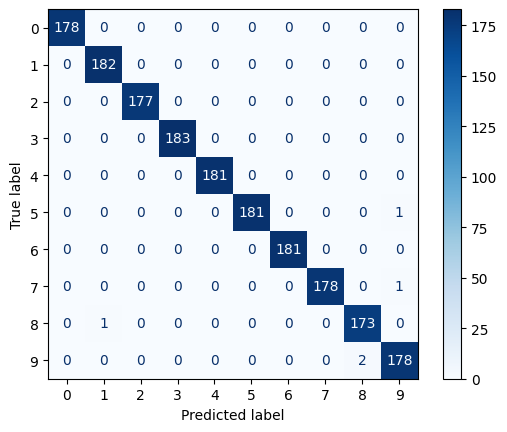

In [9]:
# Matriz de confusion sobre el dataset completo

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(estimator, data, target, cmap="Blues")
plt.show()

In [10]:
# Serializacion del artefacto evaluado por el calificador

import pickle

with open("../submission/estimator.pkl", "wb") as file:
    pickle.dump(estimator, file)